 https://chemcoord.readthedocs.io/en/v2.0.5/src_Cartesian/src_Cartesian/chemcoord.Cartesian.get_grad_zmat.html#chemcoord.Cartesian.get_grad_zmat

In [40]:
%matplotlib inline 
import matplotlib.pyplot as plt
import torch
import numpy as np
import pandas as pd
import chemcoord as cc
from ase.io import Trajectory

from flonacomldft.utils.silver_isomers_utils import get_construction_table
from flonacomldft.internal_coordinates import (
    rephase, deg_to_rad, Structure, get_internal_coordinates
)
from flonacomldft.utils.data_utils import (
    get_path,
    load_zmat_csv,
    # load_from_pickle,
    # save_pickle_file
)


In [4]:
is1 = load_zmat_csv('is1')
n_samples = 10
ys = is1[:n_samples, :-1]
ys.shape

torch.Size([10, 12])

# From cartesian to internal coordinates

In [5]:
traj = Trajectory(get_path() + 'ag6_is1_lcao.traj') 
traj

In [6]:
construction_table = get_construction_table()

xyz = []
for (i, traj_) in enumerate(traj):
    if i > 2: break
    xyz.append(cc.Cartesian.from_ase_atoms(traj_))

In [7]:
xyz

[  atom          x          y    z
 0   Ag   8.000809   5.656600  8.0
 1   Ag   7.983858  10.343400  8.0
 2   Ag   6.601959   8.059975  8.0
 3   Ag   5.330772   5.712291  8.0
 4   Ag   9.386290   8.069162  8.0
 5   Ag  10.669228   5.726007  8.0,
   atom          x          y         z
 0   Ag   8.005010   5.645443  8.011195
 1   Ag   7.987106  10.347045  7.998896
 2   Ag   6.604933   8.053677  8.007011
 3   Ag   5.309354   5.717698  7.990707
 4   Ag   9.387155   8.063524  7.995468
 5   Ag  10.679359   5.740047  7.996723,
   atom          x          y         z
 0   Ag   8.008979   5.634345  8.022361
 1   Ag   7.990378  10.350545  7.997799
 2   Ag   6.607928   8.047399  8.014005
 3   Ag   5.288231   5.723111  7.981432
 4   Ag   9.387916   8.058063  7.990948
 5   Ag  10.689484   5.753972  7.993455]

In [8]:
zmat = [xyz_.get_zmat(construction_table) for xyz_ in xyz]
zmat

[  atom       b       bond    a       angle    d    dihedral
 0   Ag  origin  12.649509  e_z   50.769952  e_x   35.260447
 2   Ag       0   2.780825  e_z   94.115069  e_x -111.190557
 3   Ag       2   2.669744    0   58.634900  e_x  -41.964342
 4   Ag       2   2.784346    3  118.623015    0   -0.000000
 5   Ag       4   2.671386    2  118.512795    3   -0.000000
 1   Ag       4   2.671886    2   58.528560    3 -180.000000,
   atom       b       bond    a       angle    d    dihedral
 0   Ag  origin  12.654266  e_z   50.722088  e_x   35.192973
 2   Ag       0   2.785646  e_z   94.030515  e_x -111.096201
 3   Ag       2   2.671252    0   59.187350  e_x  -41.561406
 4   Ag       2   2.782264    3  119.213823    0   -0.776691
 5   Ag       4   2.658635    2  118.877496    3    0.695592
 1   Ag       4   2.678548    2   58.689870    3 -179.407633,
   atom       b       bond    a       angle    d    dihedral
 0   Ag  origin  12.658904  e_z   50.673948  e_x   35.126520
 2   Ag       0   2.79

In [9]:
xyz_0 = xyz[0]
print(construction_table.index)
print(construction_table)
print(xyz_0.index)
print(xyz_0)
re_indexed_construction_table = construction_table.sort_index(inplace=False)
re_indexed_construction_table


Int64Index([0, 2, 3, 4, 5, 1], dtype='int64')
        b    a    d
0  origin  e_z  e_x
2       0  e_z  e_x
3       2    0  e_x
4       2    3    0
5       4    2    3
1       4    2    3
RangeIndex(start=0, stop=6, step=1)
  atom          x          y    z
0   Ag   8.000809   5.656600  8.0
1   Ag   7.983858  10.343400  8.0
2   Ag   6.601959   8.059975  8.0
3   Ag   5.330772   5.712291  8.0
4   Ag   9.386290   8.069162  8.0
5   Ag  10.669228   5.726007  8.0


,b,a,d
0,origin,e_z,e_x
1,4,2,3
2,0,e_z,e_x
3,2,0,e_x
4,2,3,0
5,4,2,3


In [10]:
jacobian_matrix_cart_to_ic = xyz_0.get_grad_zmat(re_indexed_construction_table, as_function=False)
jac_square = jacobian_matrix_cart_to_ic.reshape(18, 18)
np.linalg.slogdet(jac_square)

(-1.0, -14.228776252170437)

In [11]:
zmat_0 = zmat[0]
jacobian_matrix_ic_to_cart = zmat_0.get_grad_cartesian(as_function=False)
jacobian_matrix_ic_to_cart.shape
jac_square = jacobian_matrix_ic_to_cart.reshape(18, 18)
np.linalg.slogdet(jac_square)


(-1.0, 14.228776252170439)

# Functions and looking at distributions 

In [32]:
def logdetjac_to_xyz(zmat, structure): 
    """"
    zmat: array of internal coordinates for a single configuration (12,)
    """
    zmat_matrix = structure.build_zmat_matrix(zmat)
    return np.linalg.slogdet(zmat_matrix.get_grad_cartesian(as_function=False).reshape(18,18))

In [46]:
is1 = load_zmat_csv('is1')
structure = Structure()
n_samples = 2000
indx = np.random.choice(is1.shape[0], n_samples, replace=False)

logdetjacs = []
signs = []

for i in indx:
    zmat = is1[i, :-1]
    sign, logdetjac = logdetjac_to_xyz(zmat, structure)
    logdetjacs.append(logdetjac)
    signs.append(sign)


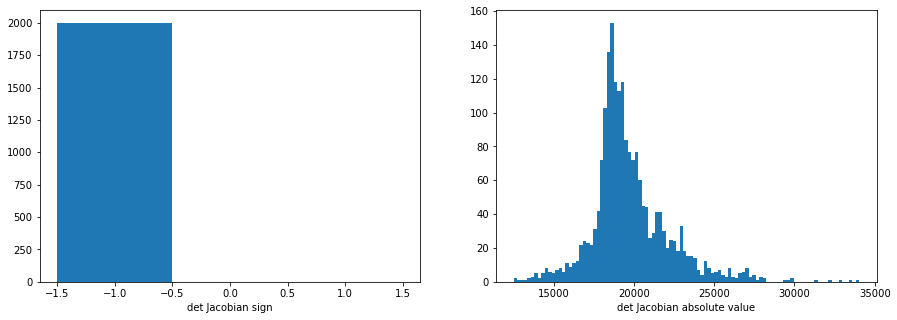

In [50]:
plt.figure(figsize=(15,5))
ax = plt.subplot(121)
plt.hist(signs, bins=[-1.5,-0.5,0.5, 1.5])
plt.xlabel('det Jacobian sign')
ax = plt.subplot(122)
plt.hist(np.exp(logdetjacs), bins=100)
plt.xlabel('det Jacobian absolute value')
plt.show()


In [48]:
is2 = load_zmat_csv('is2')
structure = Structure()
n_samples = 2000
indx = np.random.choice(is2.shape[0], n_samples, replace=False)

logdetjacs = []
signs = []

for i in indx:
    zmat = is2[i, :-1]
    sign, logdetjac = logdetjac_to_xyz(zmat, structure)
    logdetjacs.append(logdetjac)
    signs.append(sign)


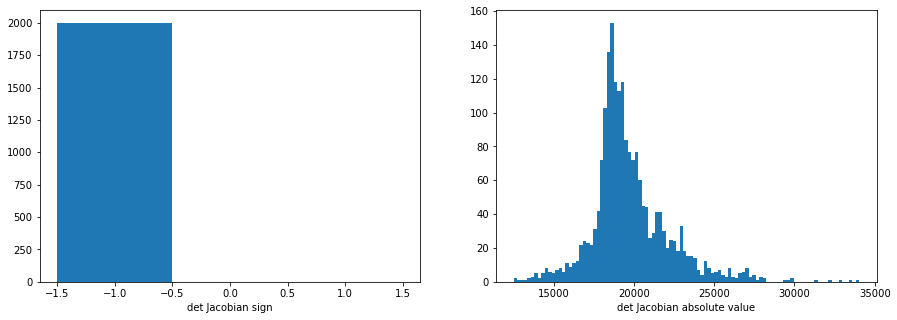

In [51]:
plt.figure(figsize=(15,5))
ax = plt.subplot(121)
plt.hist(signs, bins=[-1.5,-0.5,0.5, 1.5])
plt.xlabel('det Jacobian sign')
ax = plt.subplot(122)
plt.hist(np.exp(logdetjacs), bins=100)
plt.xlabel('det Jacobian absolute value')
plt.show()